# Analysis of Model Performance on BayesEval

We have three research questions in mind for this analysis:

**RQ 1:** What is the nature of LLM calibration
<br>
**RQ 2:** What role does task difficulty play in model calibration? 
<br>
**RQ 3:** Does prompting models to output SPDs improve calibration?
<br>

In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


ROOT_DIR = Path("..").resolve()
RESULTS_PATH = ROOT_DIR / Path("results")
FIGURES_PATH = "figs/"
MODELS = ["anthropic_claude-haiku-4.5", "google_gemini-2.5-flash", "meta-llama_llama-4-maverick", "openai_gpt-5.4-mini"]
MODEL_LABELS = ["Claude Haiku 4.5", "Gemini 2.5 Flash", "Llama 4 Maverick", "GPT-5.4 Mini"]

_tab10 = sns.color_palette("tab10", len(MODELS))
MODEL_COLORS = dict(zip(MODELS, _tab10))

# 11 bins: [0.0,0.1), [0.1,0.2), ..., [0.9,1.0), [1.0]
BIN_EDGES = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.01]
BIN_LABELS = ["[0.0,0.1)", "[0.1,0.2)", "[0.2,0.3)", "[0.3,0.4)", "[0.4,0.5)",
              "[0.5,0.6)", "[0.6,0.7)", "[0.7,0.8)", "[0.8,0.9)", "[0.9,1.0)", "[1.0]"]
BIN_MIDPOINTS = np.array([0.05, 0.15, 0.25, 0.35, 0.45, 0.55, 0.65, 0.75, 0.85, 0.95, 1.0])

SIZE_MIN, SIZE_MAX = 20, 200

def calibration_plot(ax, df, correct_col, title):
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
    for model, label in zip(MODELS, MODEL_LABELS):
        model_df = df[df["model"] == model].copy()
        model_df["bin"] = pd.cut(model_df["Confidence"], bins=BIN_EDGES,
                                 right=False, labels=BIN_LABELS, include_lowest=True)
        bin_stats = model_df.groupby("bin", observed=False).agg(
            frac_correct=(correct_col, "mean"),
            count=(correct_col, "count")
        ).reset_index()
        p = bin_stats["frac_correct"].values
        n = bin_stats["count"].values
        mask = n > 0
        n_max = n[mask].max() if mask.any() else 1
        sizes = SIZE_MIN + (SIZE_MAX - SIZE_MIN) * n[mask] / n_max
        color = MODEL_COLORS[model]
        ax.plot(BIN_MIDPOINTS[mask], p[mask], color=color, linewidth=1.5, alpha=0.8)
        ax.scatter(BIN_MIDPOINTS[mask], p[mask], s=sizes, color=color,
                   label=label, edgecolors="white", linewidths=0.5, zorder=3)
    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Confidence")
    ax.set_title(title, fontsize=11)
    ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.grid(alpha=0.3)


# Weight Guessing Dataset (WGD)

In [109]:
wgd_df = pd.DataFrame()
wgd_path = RESULTS_PATH / Path("WGD")
for model in MODELS:
    new_df_path = wgd_path / Path(f"{model}.csv")
    new_df = pd.read_csv(new_df_path)
    new_df["model"] = model
    wgd_df = pd.concat([wgd_df, new_df])
    
wgd_df.reset_index(inplace = True)
wgd_df.tail()

,index,question_id,Answer,Confidence,raw,error,photo,within_lbs,true_weight,model
18555,4635,wgd_301_16,155.0,0.62,"{""Answer"":""155"",""Confidence"":""0.62""}",NaN,301.jpg,16,150.0,openai_gpt-5.4-mini
18556,4636,wgd_301_17,150.0,0.43,"{""Answer"":""150"",""Confidence"":""0.43""}",NaN,301.jpg,17,150.0,openai_gpt-5.4-mini
18557,4637,wgd_301_18,150.0,0.52,"{""Answer"":""150"",""Confidence"":""0.52""}",NaN,301.jpg,18,150.0,openai_gpt-5.4-mini
18558,4638,wgd_301_19,150.0,0.52,"{""Answer"":""150"",""Confidence"":""0.52""}",NaN,301.jpg,19,150.0,openai_gpt-5.4-mini
18559,4639,wgd_301_20,155.0,0.56,"{""Answer"":""155"",""Confidence"":""0.56""}",NaN,301.jpg,20,150.0,openai_gpt-5.4-mini


In [110]:
# RQ 1)
# Score WGD
# WGD Calibration: correct if |Answer - true_weight| <= within_lbs

wgd_df["Answer_num"] = pd.to_numeric(wgd_df["Answer"], errors="coerce")
wgd_df = wgd_df.dropna(subset=["Answer_num"])
wgd_df["correct"] = (np.abs(wgd_df["Answer_num"] - wgd_df["true_weight"]) <= wgd_df["within_lbs"]).astype(int)

# LifeEval

In [111]:
df = pd.DataFrame()
le_path = RESULTS_PATH / Path("LifeEval")
for model in MODELS:
    new_df_path = le_path / Path(f"{model}.csv")
    new_df = pd.read_csv(new_df_path)
    new_df["model"] = model
    df = pd.concat([df, new_df])
    
df.reset_index(inplace = True)
df.tail()

,index,question_id,Answer,Confidence,raw,error,true_lifespan,min_age,sex,radius,...,sex_x,radius_x,best_answer_x,MAS_x,true_lifespan_y,min_age_y,sex_y,radius_y,best_answer_y,MAS_y
16155,4035,4035,102,0.78,"{""Answer"":""102"",""Confidence"":""0.78""}",NaN,102.14,100.0,female,16.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16156,4036,4036,103,0.72,"{""Answer"":""103"",""Confidence"":""0.72""}",NaN,102.14,100.0,female,17.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16157,4037,4037,101,0.72,"{""Answer"":""101"",""Confidence"":""0.72""}",NaN,102.14,100.0,female,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16158,4038,4038,101,0.72,"{""Answer"":""101"",""Confidence"":""0.72""}",NaN,102.14,100.0,female,19.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16159,4039,4039,103,0.72,"{""Answer"":""103"",""Confidence"":""0.72""}",NaN,102.14,100.0,female,20.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [112]:
# RQ 1)
# LifeEval Calibration: true_probability via Gompertz conditional survival CDF

from scoring import lifeeval_true_probability

LIFEEVAL_COLS = ["question_id", "Answer", "Confidence", "raw", "error",
                 "true_lifespan", "min_age", "sex", "radius", "best_answer", "MAS"]

le_df = pd.DataFrame()
le_path = RESULTS_PATH / Path("LifeEval")
for model in MODELS:
    new_df = pd.read_csv(le_path / f"{model}.csv")
    # Normalize mangled _x/_y columns from prior double-merges
    rename = {}
    for col in LIFEEVAL_COLS:
        if col not in new_df.columns and f"{col}_x" in new_df.columns:
            rename[f"{col}_x"] = col
    if rename:
        new_df = new_df.rename(columns=rename)
    new_df = new_df[[c for c in LIFEEVAL_COLS if c in new_df.columns] + ["model"] if "model" in new_df.columns else [c for c in LIFEEVAL_COLS if c in new_df.columns]]
    new_df["model"] = model
    le_df = pd.concat([le_df, new_df], ignore_index=True)

le_df["Answer_num"] = pd.to_numeric(le_df["Answer"], errors="coerce")
le_df = le_df.dropna(subset=["Answer_num", "sex", "min_age", "radius"])
le_df["true_probability"] = [
    lifeeval_true_probability(a, age, sex, r)
    for a, age, sex, r in zip(le_df["Answer_num"], le_df["min_age"], le_df["sex"], le_df["radius"])
]

# MedEval

In [113]:
df = pd.DataFrame()
me_path = RESULTS_PATH / Path("MedEval")
for model in MODELS:
    new_df_path = me_path / Path(f"{model}.csv")
    new_df = pd.read_csv(new_df_path)
    new_df["model"] = model
    df = pd.concat([df, new_df])
    
df.reset_index(inplace = True)
df.tail()

,index,question_id,Answer,Confidence,raw,error,age,sex,true_pathology,differential_json,removal_pct,model
6907,1723,med_test_00427_r50,Possible NSTEMI / STEMI,0.89,"{""Answer"":""Possible NSTEMI / STEMI"",""Confidenc...",NaN,60,F,Stable angina,"[[""Unstable angina"", 0.32453425744095565], [""S...",50,openai_gpt-5.4-mini
6908,1724,med_test_00428_r50,Acute otitis media,0.93,"{""Answer"":""Acute otitis media"",""Confidence"":""0...",NaN,21,F,Acute otitis media,"[[""Acute otitis media"", 1.0]]",50,openai_gpt-5.4-mini
6909,1725,med_test_00429_r50,Pancreatic neoplasm,0.72,"{""Answer"":""Pancreatic neoplasm"",""Confidence"":""...",NaN,46,M,Boerhaave,"[[""Atrial fibrillation"", 0.21184837992379507],...",50,openai_gpt-5.4-mini
6910,1726,med_test_00430_r50,Anemia,0.99,"{""Answer"":""Anemia"",""Confidence"":""0.99""}",NaN,21,F,Anemia,"[[""Anemia"", 0.15603505897738762], [""Atrial fib...",50,openai_gpt-5.4-mini
6911,1727,med_test_00431_r50,Acute dystonic reactions,0.99,"{""Answer"":""Acute dystonic reactions"",""Confiden...",NaN,69,F,Acute dystonic reactions,"[[""Acute dystonic reactions"", 0.18614785670316...",50,openai_gpt-5.4-mini


In [114]:
# RQ 1)
# MedEval Calibration: correct if Answer matches true_pathology
me_df = pd.DataFrame()
me_path = RESULTS_PATH / Path("MedEval")
for model in MODELS:
    new_df = pd.read_csv(me_path / f"{model}.csv")
    new_df["model"] = model
    me_df = pd.concat([me_df, new_df], ignore_index=True)

me_df["correct"] = (me_df["Answer"].str.strip().str.lower() == me_df["true_pathology"].str.strip().str.lower()).astype(int)

In [115]:
me_df[me_df["removal_pct"] == 50]

,question_id,Answer,Confidence,raw,error,age,sex,true_pathology,differential_json,removal_pct,model,correct
1296,med_test_00000_r50,Pulmonary neoplasm,0.78,"```json\n{""Answer"": ""Pulmonary neoplasm"", ""Con...",NaN,51,M,Pulmonary neoplasm,"[[""Pulmonary neoplasm"", 0.09211184674852994], ...",50,anthropic_claude-haiku-4.5,1
1297,med_test_00001_r50,Possible NSTEMI / STEMI,0.85,"```json\n{""Answer"": ""Possible NSTEMI / STEMI"",...",NaN,49,M,Stable angina,"[[""Possible NSTEMI / STEMI"", 0.118115396079655...",50,anthropic_claude-haiku-4.5,0
1298,med_test_00002_r50,Possible NSTEMI / STEMI,0.78,"```json\n{""Answer"": ""Possible NSTEMI / STEMI"",...",NaN,34,F,Stable angina,"[[""SLE"", 0.11115121883558775], [""Possible NSTE...",50,anthropic_claude-haiku-4.5,0
1299,med_test_00003_r50,Pericarditis,0.75,"```json\n{""Answer"": ""Pericarditis"", ""Confidenc...",NaN,29,M,Acute pulmonary edema,"[[""Acute pulmonary edema"", 0.08484635918186363...",50,anthropic_claude-haiku-4.5,0
1300,med_test_00004_r50,Pneumonia,0.72,"```json\n{""Answer"": ""Pneumonia"", ""Confidence"":...",NaN,49,M,Influenza,"[[""Influenza"", 0.20744965435060425], [""Bronchi...",50,anthropic_claude-haiku-4.5,0
...,...,...,...,...,...,...,...,...,...,...,...,...
6907,med_test_00427_r50,Possible NSTEMI / STEMI,0.89,"{""Answer"":""Possible NSTEMI / STEMI"",""Confidenc...",NaN,60,F,Stable angina,"[[""Unstable angina"", 0.32453425744095565], [""S...",50,openai_gpt-5.4-mini,0
6908,med_test_00428_r50,Acute otitis media,0.93,"{""Answer"":""Acute otitis media"",""Confidence"":""0...",NaN,21,F,Acute otitis media,"[[""Acute otitis media"", 1.0]]",50,openai_gpt-5.4-mini,1
6909,med_test_00429_r50,Pancreatic neoplasm,0.72,"{""Answer"":""Pancreatic neoplasm"",""Confidence"":""...",NaN,46,M,Boerhaave,"[[""Atrial fibrillation"", 0.21184837992379507],...",50,openai_gpt-5.4-mini,0
6910,med_test_00430_r50,Anemia,0.99,"{""Answer"":""Anemia"",""Confidence"":""0.99""}",NaN,21,F,Anemia,"[[""Anemia"", 0.15603505897738762], [""Atrial fib...",50,openai_gpt-5.4-mini,1


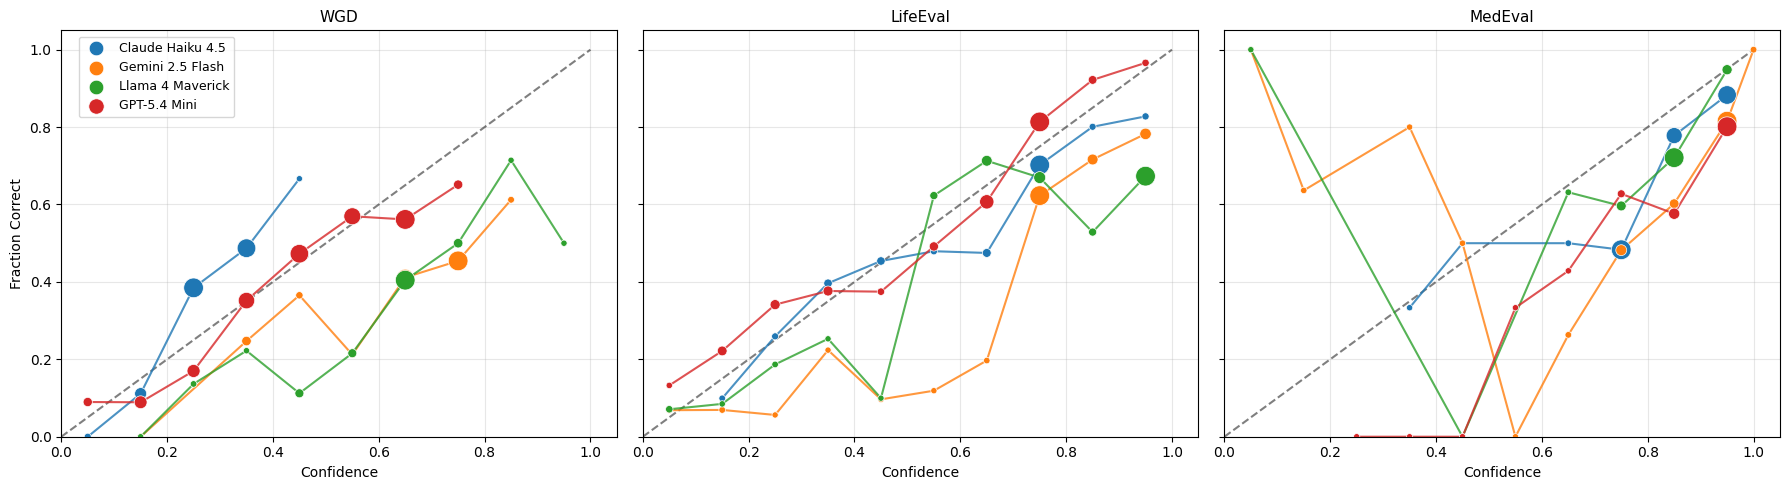

In [116]:
# RQ 1) Combined calibration plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
#fig.suptitle("Calibration Curves", fontsize=14, y=1.02)

calibration_plot(axes[0], wgd_df, "correct", "WGD")
calibration_plot(axes[1], le_df, "true_probability", "LifeEval")
calibration_plot(axes[2], me_df, "correct", "MedEval")

axes[0].set_ylabel("Fraction Correct")
axes[0].legend(bbox_to_anchor=(0.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
Path(FIGURES_PATH).mkdir(exist_ok=True)
fig.savefig(f"{FIGURES_PATH}/calibration_combined.png", dpi=150, bbox_inches="tight")
plt.show()

In [117]:
# RQ 1) Summary table: Accuracy, Mean Confidence, ECE by Domain × Model

from scoring import medeval_true_probability

def compute_ece(conf, outcome, bin_edges=BIN_EDGES):
    bins = pd.cut(conf, bins=bin_edges, right=False, include_lowest=True)
    grouped = pd.DataFrame({"conf": conf.values, "outcome": outcome.values, "bin": bins.values}).groupby("bin", observed=False)
    n = grouped.size()
    total = n.sum()
    if total == 0:
        return np.nan
    acc_per_bin = grouped["outcome"].mean()
    conf_per_bin = grouped["conf"].mean()
    return (n / total * (acc_per_bin - conf_per_bin).abs()).sum()

# Compute true_probability for MedEval if not already present
if "true_probability" not in me_df.columns:
    me_df["true_probability"] = [
        medeval_true_probability(a, d)
        for a, d in zip(me_df["Answer"], me_df["differential_json"])
    ]

rows = []
for domain, ddf, outcome_col in [
    ("WGD", wgd_df, "correct"),
    ("LifeEval", le_df, "true_probability"),
    ("MedEval", me_df, "true_probability"),
]:
    for model, label in zip(MODELS, MODEL_LABELS):
        sub = ddf[ddf["model"] == model]
        mean_conf = sub["Confidence"].mean()
        mean_acc = sub[outcome_col].mean()
        rows.append({
            "Domain": domain,
            "Model": label,
            "Accuracy": mean_acc,
            "Mean Confidence": mean_conf,
            "Overconfidence": mean_conf - mean_acc,
            "ECE": compute_ece(sub["Confidence"], sub[outcome_col]),
        })

summary = pd.DataFrame(rows).set_index(["Domain", "Model"])
summary.style.format("{:.3f}")

# RQ 2) Overconfidence by Task Difficulty

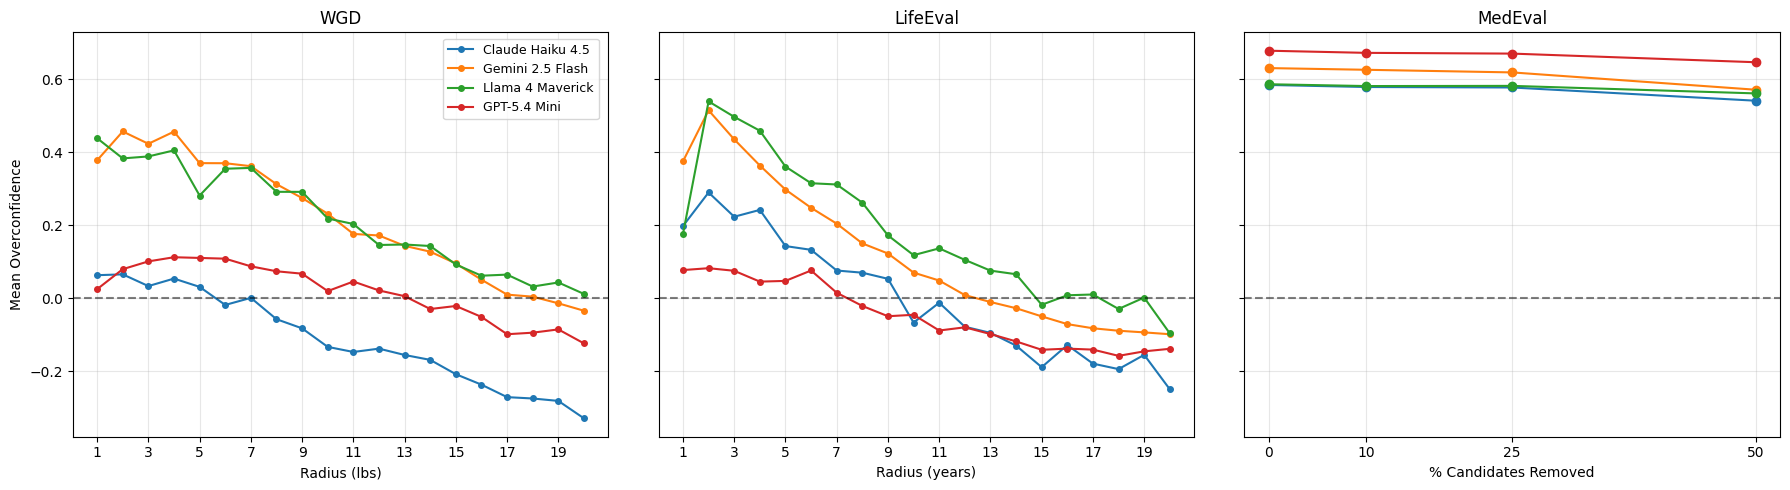

In [118]:
# RQ 2) Overconfidence by difficulty
# WGD: true_probability is binary (correct), difficulty = within_lbs
# LifeEval: true_probability via Gompertz, difficulty = radius
# MedEval: true_probability via differential lookup, difficulty = removal_pct

from scoring import medeval_true_probability

# --- Compute overconfidence for each domain ---
wgd_df["overconfidence"] = wgd_df["Confidence"] - wgd_df["correct"]

le_df["overconfidence"] = le_df["Confidence"] - le_df["true_probability"]

me_df["true_probability"] = [
    medeval_true_probability(a, d)
    for a, d in zip(me_df["Answer"], me_df["differential_json"])
]
me_df["overconfidence"] = me_df["Confidence"] - me_df["true_probability"]

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
#fig.suptitle("Overconfidence by Task Difficulty", fontsize=14, y=1.02)

# WGD
ax = axes[0]
for model, label in zip(MODELS, MODEL_LABELS):
    sub = wgd_df[wgd_df["model"] == model]
    grouped = sub.groupby("within_lbs")["overconfidence"].mean()
    ax.plot(grouped.index, grouped.values, marker="o", markersize=4,
            label=label, color=MODEL_COLORS[model], linewidth=1.5)
ax.axhline(0, color="black", linestyle="--", alpha=0.5)
ax.set_xlabel("Radius (lbs)")
ax.set_ylabel("Mean Overconfidence")
ax.set_title("WGD")
ax.set_xticks(range(1, 21, 2))
ax.grid(alpha=0.3)

# LifeEval
ax = axes[1]
for model, label in zip(MODELS, MODEL_LABELS):
    sub = le_df[le_df["model"] == model]
    grouped = sub.groupby("radius")["overconfidence"].mean()
    ax.plot(grouped.index, grouped.values, marker="o", markersize=4,
            label=label, color=MODEL_COLORS[model], linewidth=1.5)
ax.axhline(0, color="black", linestyle="--", alpha=0.5)
ax.set_xlabel("Radius (years)")
ax.set_title("LifeEval")
ax.set_xticks(range(1, 21, 2))
ax.grid(alpha=0.3)

# MedEval
ax = axes[2]
for model, label in zip(MODELS, MODEL_LABELS):
    sub = me_df[me_df["model"] == model]
    grouped = sub.groupby("removal_pct")["overconfidence"].mean()
    ax.plot(grouped.index, grouped.values, marker="o", markersize=6,
            label=label, color=MODEL_COLORS[model], linewidth=1.5)
ax.axhline(0, color="black", linestyle="--", alpha=0.5)
ax.set_xlabel("% Candidates Removed")
ax.set_title("MedEval")
ax.set_xticks([0, 10, 25, 50])
ax.grid(alpha=0.3)

axes[0].legend(bbox_to_anchor=(0.68, 1), loc="upper left", fontsize=9)
plt.tight_layout()
Path(FIGURES_PATH).mkdir(exist_ok=True)
fig.savefig(f"{FIGURES_PATH}/overconfidence_by_difficulty.png", dpi=150, bbox_inches="tight")
plt.show()